In [1]:
import torch
from collections import defaultdict

In [2]:
from collections.abc import Callable, Iterable
from typing import Optional
import torch
import math
class SGD(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3):
        if lr < 0:
            raise ValueError(f"Invalid learning rate: {lr}")
        defaults = {"lr": lr}
        super().__init__(params, defaults)
    
    def step(self, closure: Optional[Callable] = None):
        loss = None if closure is None else closure()
        for group in self.param_groups:
            lr = group["lr"] # Get the learning rate.
            for p in group["params"]:
                if p.grad is None:
                    continue
            state = self.state[p] # Get state associated with p.
            t = state.get("t", 0) # Get iteration number from the state, or initial value.
            grad = p.grad.data # Get the gradient of loss with respect to p.
            p.data -= lr / math.sqrt(t + 1) * grad # Update weight tensor in-place.
            state["t"] = t + 1 # Increment iteration number.
        return loss

In [3]:
initial_weight_values = 5 * torch.randn((10, 10))
learning_rates = [1e-1, 1e0, 1e1, 1e2, 1e3]
iterations = 10
results = defaultdict(list)

for lr in learning_rates:
    weights = torch.nn.Parameter(5 * torch.empty((10, 10)))
    weights.data = initial_weight_values.clone()
    opt = SGD([weights], lr=lr)
    for t in range(iterations):
        opt.zero_grad() # Reset the gradients for all learnable parameters.
        loss = (weights**2).mean() # Compute a scalar loss value.
        # print(loss.cpu().item())
        loss.backward() # Run backward pass, which computes gradients.
        opt.step() # Run optimizer step.
        results[lr].append(loss.cpu().item())

<function matplotlib.pyplot.show(close=None, block=None)>

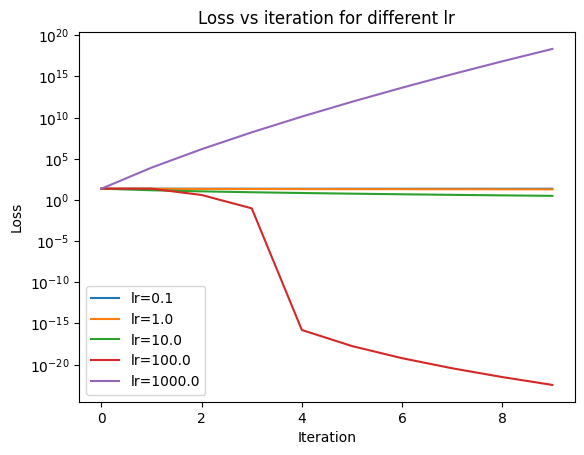

In [4]:
import matplotlib.pyplot as plt

for lr in learning_rates:
    plt.plot(results[lr], label=f'lr={lr}')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.title('Loss vs iteration for different lr')
plt.show

In [7]:
def learning_rate_schedule(
    t: int,
    lr_max: float,
    lr_min: float,
    t_w: int,
    t_c: int,
) -> float:

    # warmup
    if t < t_w:
        return (t / t_w) * lr_max

    # cosine annealing
    if t < t_c:
        return lr_min + 0.5 * (1 + math.cos(math.pi * (t - t_w) / (t_c - t_w))) * (lr_max - lr_min)

    # post-annealing
    return lr_min 

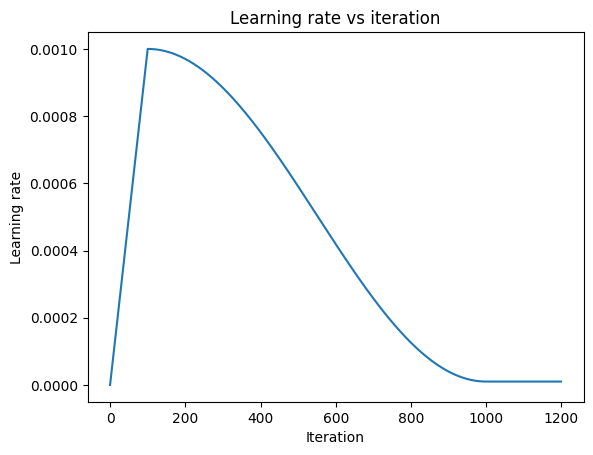

In [12]:
lr_max = 1e-3
lr_min = 1e-5
t_w = 1e2
t_c = 1e3
t_tot = t_w + t_c + t_w

schedule = [learning_rate_schedule(i, lr_max, lr_min, t_w, t_c) for i in range(int(t_tot))]

plt.plot(schedule)

plt.xlabel('Iteration')
plt.ylabel('Learning rate')
plt.title('Learning rate vs iteration')
plt.show

plt.show()